In [3]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)

# Style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10,6)

In [4]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/imakash3011/customer-personality-analysis/marketing_campaign.csv


In [9]:
df = pd.read_csv("/kaggle/input/datasets/imakash3011/customer-personality-analysis/marketing_campaign.csv", sep="\t")
df.head()
df.tail()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,43,182,42,118,247,2,9,3,4,5,0,0,0,0,0,0,3,11,0
2236,4001,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406,0,30,0,0,8,7,8,2,5,7,0,0,0,1,0,0,3,11,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,48,217,32,12,24,1,2,3,13,6,0,1,0,0,0,0,3,11,0
2238,8235,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,30,214,80,30,61,2,6,5,10,3,0,0,0,0,0,0,3,11,0
2239,9405,1954,PhD,Married,52869.0,1,1,15-10-2012,40,84,3,61,2,1,21,3,3,1,4,7,0,0,0,0,0,0,3,11,1


In [11]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])
df.info()
df.describe()
df.describe(include='object')


Rows : 2240
Columns : 29
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurch

,Education,Marital_Status,Dt_Customer
count,2240,2240,2240
unique,5,8,663
top,Graduation,Married,31-08-2012
freq,1127,864,12


In [12]:
df.isnull().sum()
(df.isnull().sum()/len(df))*100
df.duplicated().sum()
df.nunique()
df.dtypes

ID                       int64
Year_Birth               int64
Education               object
Marital_Status          object
Income                 float64
Kidhome                  int64
Teenhome                 int64
Dt_Customer             object
Recency                  int64
MntWines                 int64
MntFruits                int64
MntMeatProducts          int64
MntFishProducts          int64
MntSweetProducts         int64
MntGoldProds             int64
NumDealsPurchases        int64
NumWebPurchases          int64
NumCatalogPurchases      int64
NumStorePurchases        int64
NumWebVisitsMonth        int64
AcceptedCmp3             int64
AcceptedCmp4             int64
AcceptedCmp5             int64
AcceptedCmp1             int64
AcceptedCmp2             int64
Complain                 int64
Z_CostContact            int64
Z_Revenue                int64
Response                 int64
dtype: object

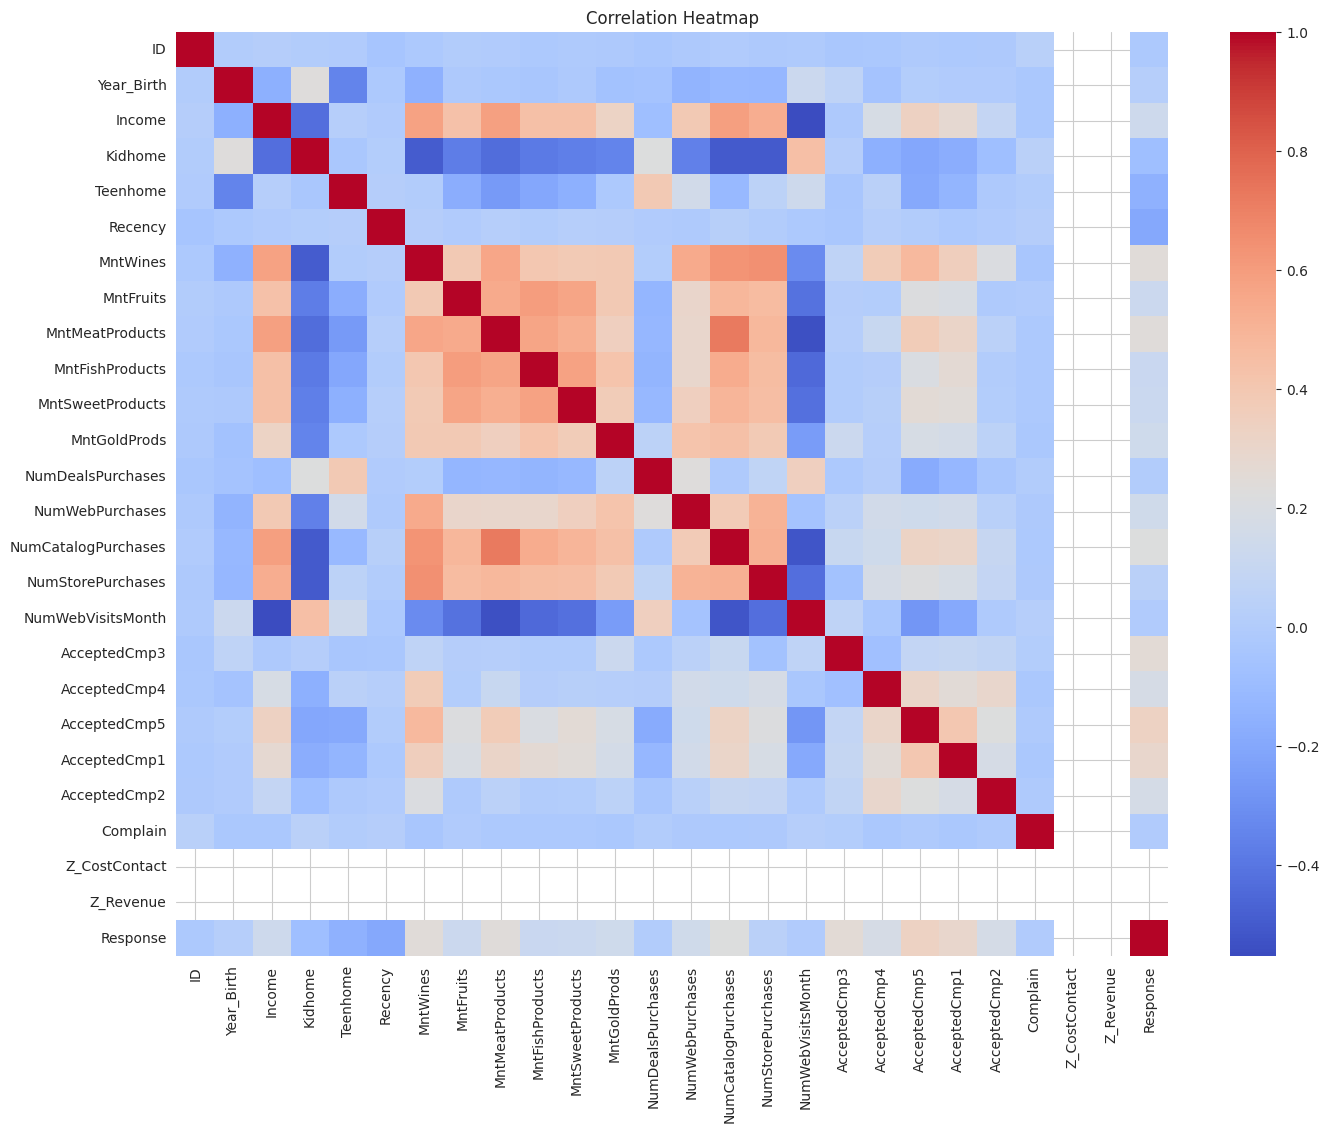

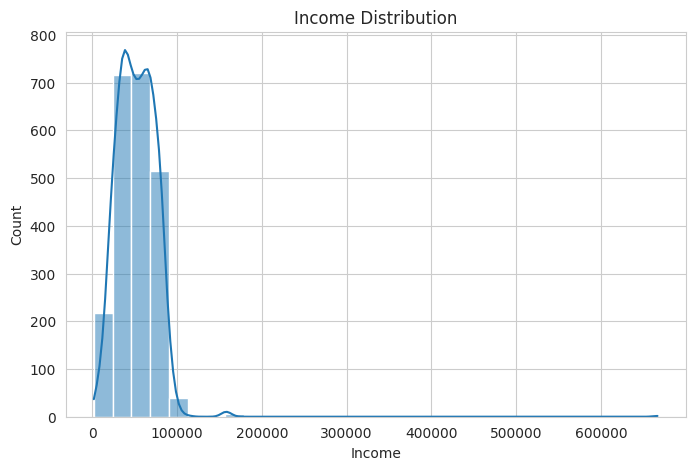

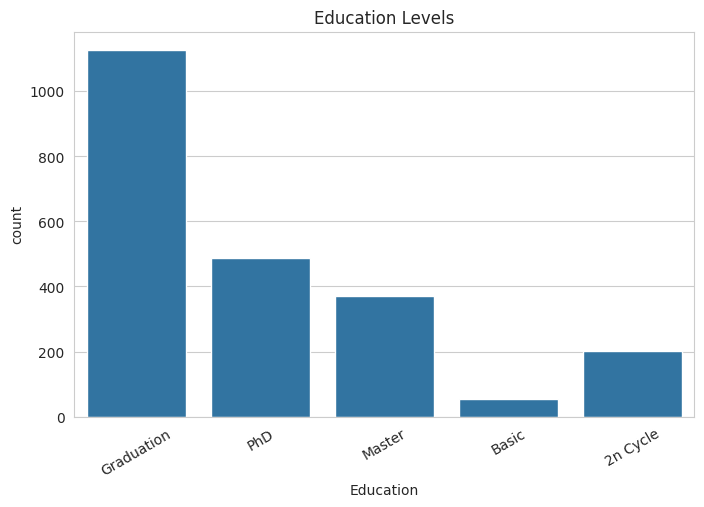

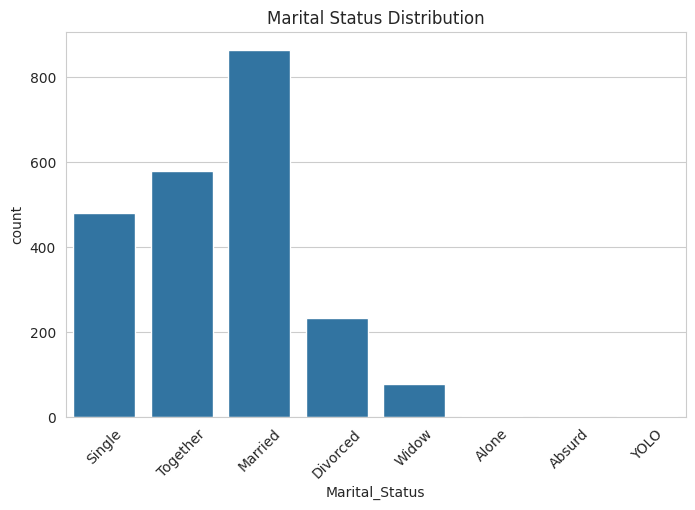

In [13]:
plt.figure(figsize=(16,12))

sns.heatmap(df.corr(numeric_only=True),
            cmap='coolwarm',
            annot=False)

plt.title("Correlation Heatmap")
plt.show()
plt.figure(figsize=(8,5))

sns.histplot(df['Income'],
             bins=30,
             kde=True)

plt.title("Income Distribution")
plt.show()
plt.figure(figsize=(8,5))

sns.countplot(x='Education',
              data=df)

plt.xticks(rotation=30)

plt.title("Education Levels")
plt.show()
plt.figure(figsize=(8,5))

sns.countplot(x='Marital_Status',
              data=df)

plt.xticks(rotation=45)

plt.title("Marital Status Distribution")
plt.show()

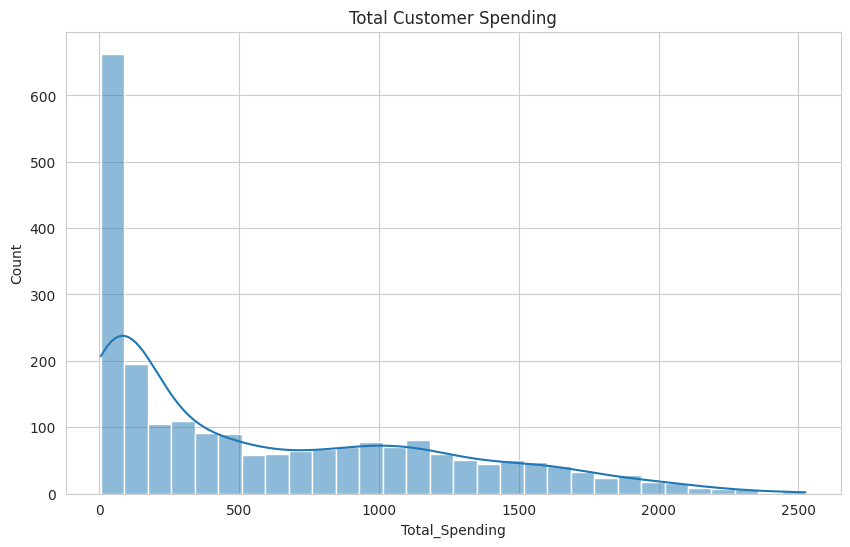

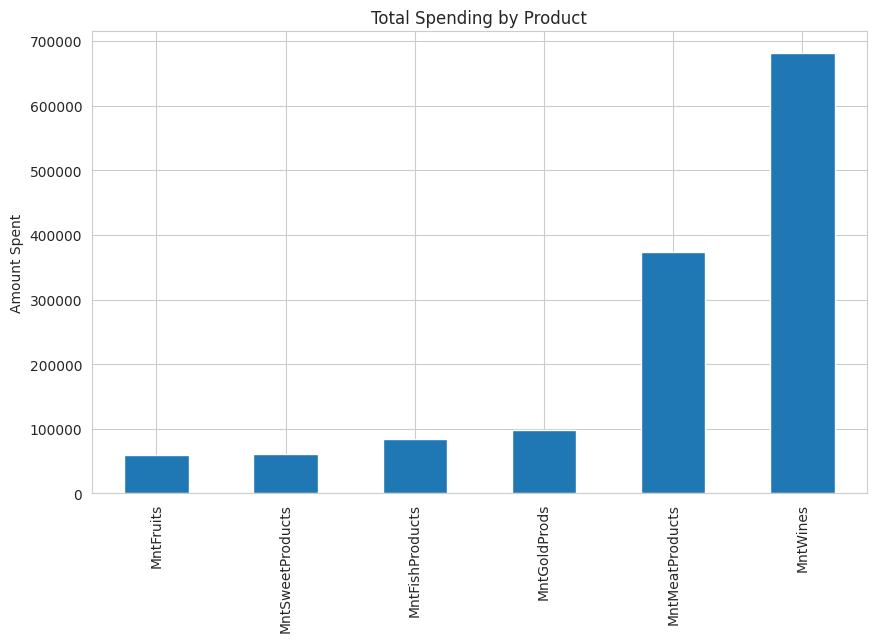

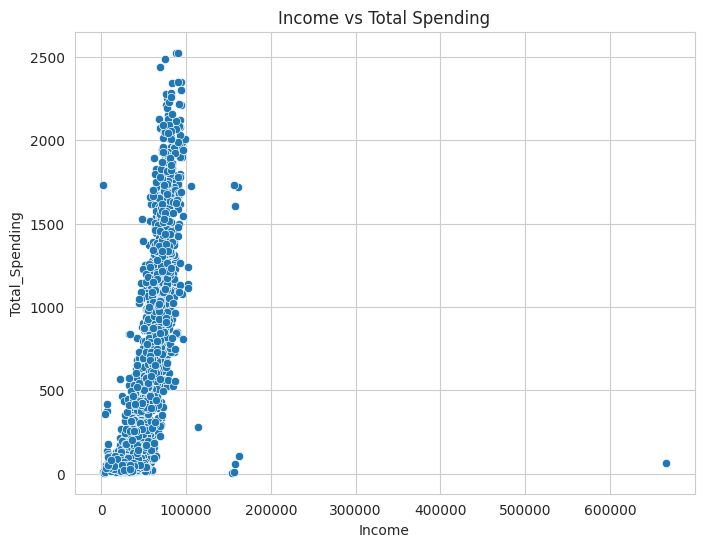

In [14]:
df['Total_Spending'] = (
    df['MntWines'] +
    df['MntFruits'] +
    df['MntMeatProducts'] +
    df['MntFishProducts'] +
    df['MntSweetProducts'] +
    df['MntGoldProds']
)

df[['Total_Spending']].head()
sns.histplot(df['Total_Spending'],
             bins=30,
             kde=True)

plt.title("Total Customer Spending")
plt.show()
products = ['MntWines',
            'MntFruits',
            'MntMeatProducts',
            'MntFishProducts',
            'MntSweetProducts',
            'MntGoldProds']

df[products].sum().sort_values().plot(kind='bar')

plt.ylabel("Amount Spent")

plt.title("Total Spending by Product")
plt.show()
plt.figure(figsize=(8,6))

sns.scatterplot(x='Income',
                y='Total_Spending',
                data=df)

plt.title("Income vs Total Spending")

plt.show()

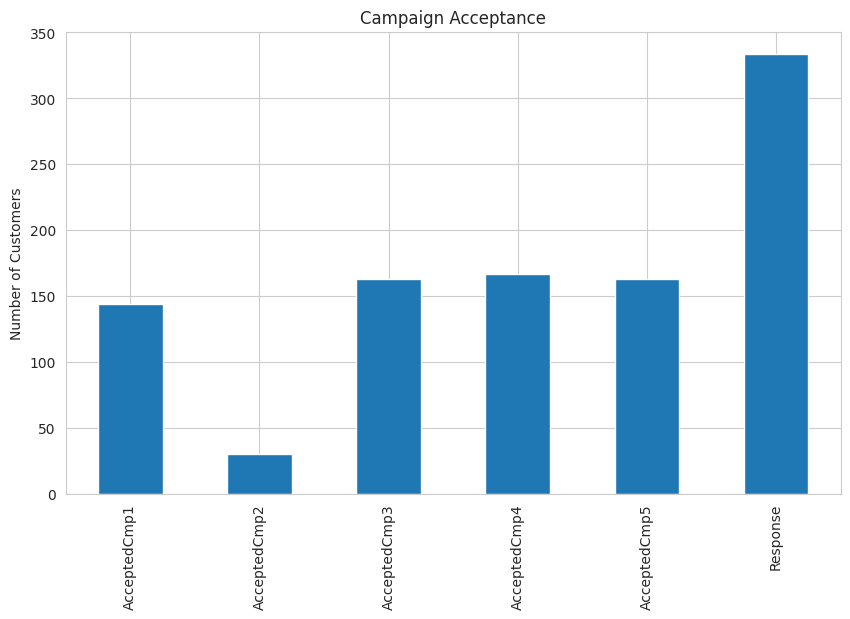

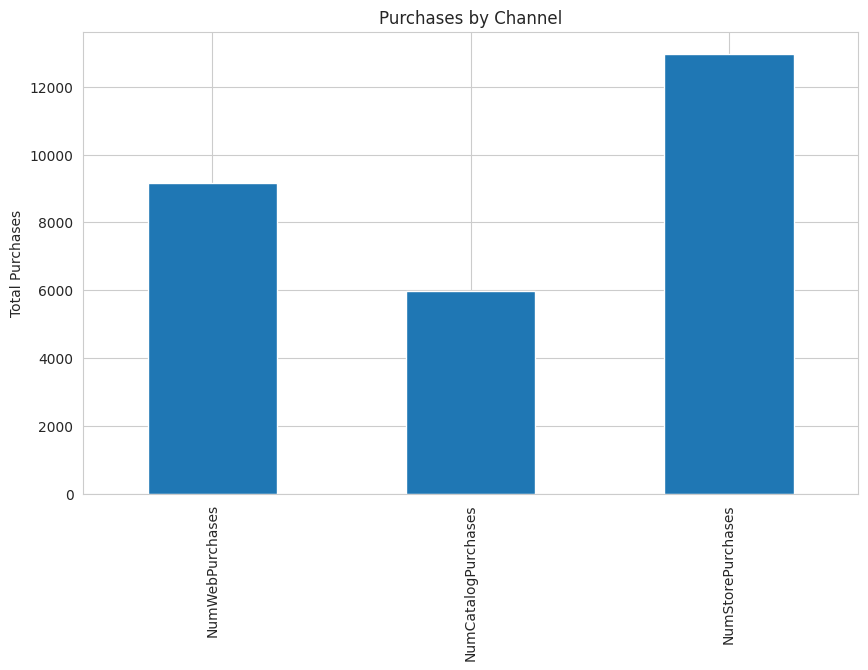

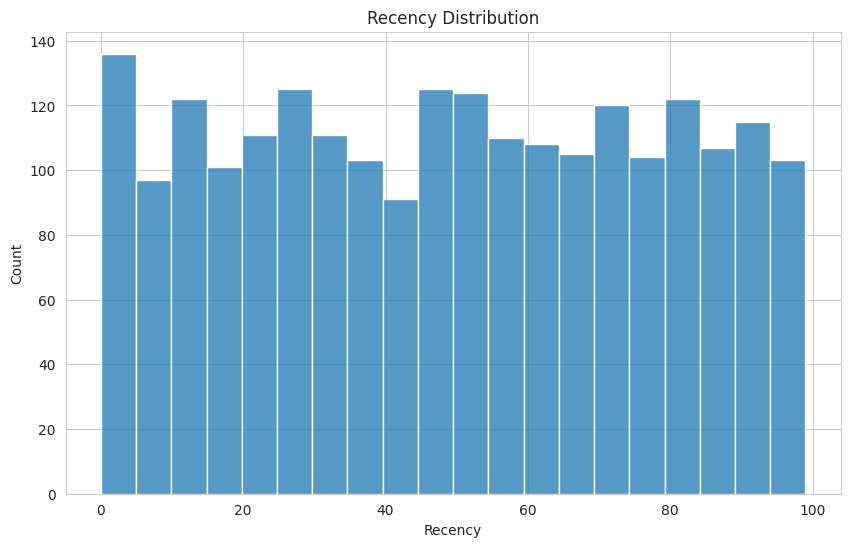

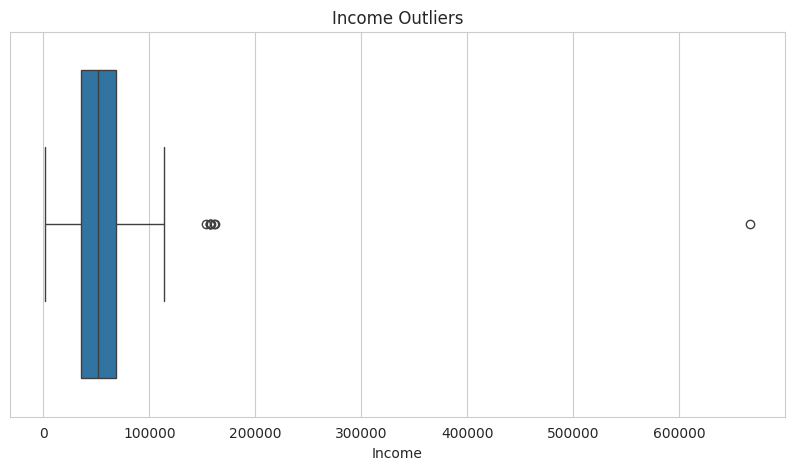

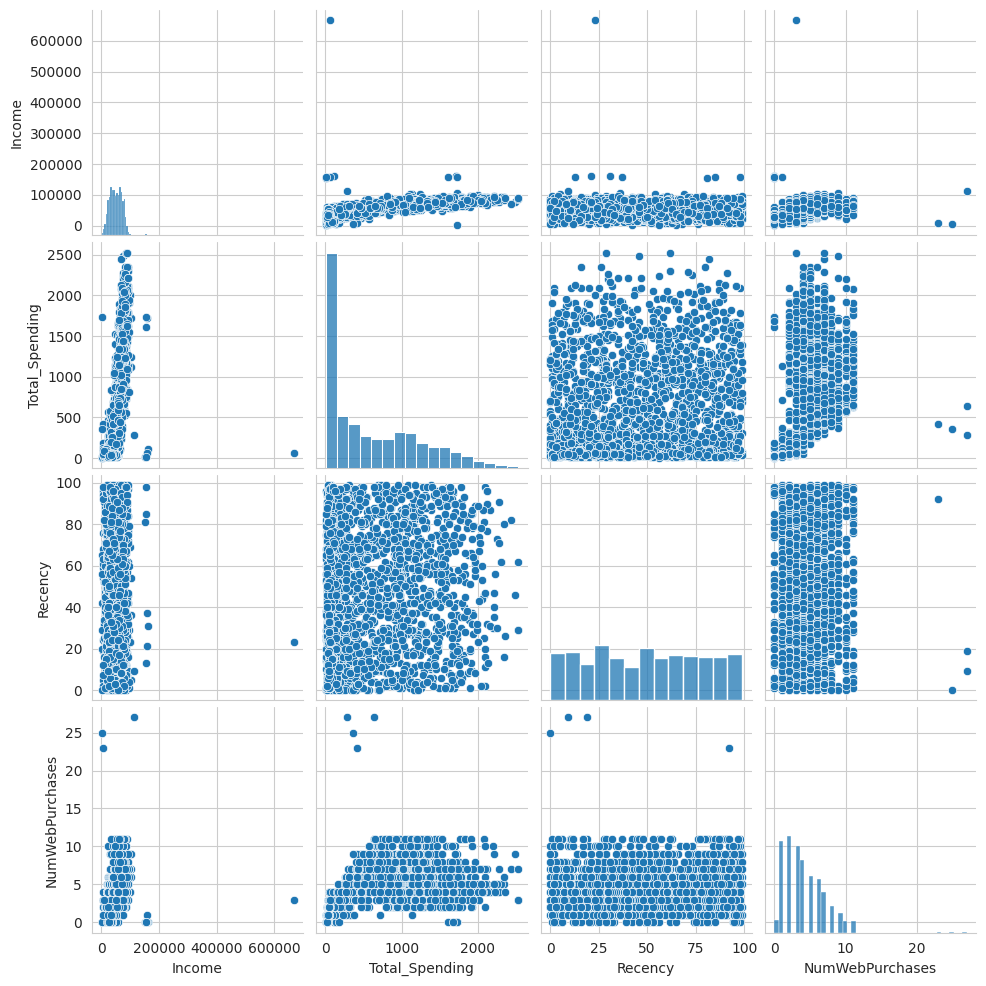

In [15]:
campaigns = ['AcceptedCmp1',
             'AcceptedCmp2',
             'AcceptedCmp3',
             'AcceptedCmp4',
             'AcceptedCmp5',
             'Response']

df[campaigns].sum().plot(kind='bar')

plt.title("Campaign Acceptance")

plt.ylabel("Number of Customers")

plt.show()
purchase = ['NumWebPurchases',
            'NumCatalogPurchases',
            'NumStorePurchases']

df[purchase].sum().plot(kind='bar')

plt.title("Purchases by Channel")

plt.ylabel("Total Purchases")

plt.show()
sns.histplot(df['Recency'],
             bins=20)

plt.title("Recency Distribution")

plt.show()
plt.figure(figsize=(10,5))

sns.boxplot(x=df['Income'])

plt.title("Income Outliers")

plt.show()
sns.pairplot(df[['Income',
                 'Total_Spending',
                 'Recency',
                 'NumWebPurchases']])

plt.show()
df.to_csv("cleaned_customer_data.csv", index=False)